# Stroop-Style CLIP Testing  
## Synthetic Dataset Generation + One-Prompt Black-Box + One-Prompt White-Box Heatmaps

This notebook is prepared as a clean version to share with my professor.

### What this notebook does

1. Generates a **synthetic Stroop-style dataset from scratch**.
2. Creates **20,000 images** using **10 color classes**.
3. Evaluates CLIP using **one fixed prompt template**.
4. Calculates accuracy and error categories.
5. Performs white-box heatmap testing using **one attribution prompt** based on the model prediction.

### Main research question

Does CLIP follow the actual **visual font color**, or does it get biased by the **written word**?

The correct label is always the **font color**.

# 1. Install dependencies

Run this first in Google Colab.

In [2]:
!pip -q install ftfy regex tqdm
!pip -q install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


# 2. Imports

In [3]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from PIL import Image, ImageDraw, ImageFont

import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

import clip

# 3. Experiment configuration

This notebook does **not** require any existing `metadata.csv`.

It generates:
- 20,000 images
- 20,000 text masks
- a new `metadata.csv`
- prediction results
- heatmap outputs

In [4]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Output folder in Colab
DATASET_ROOT = Path("/content/stroop_clip_one_prompt_dataset")
IMAGE_DIR = DATASET_ROOT / "images"
MASK_DIR = DATASET_ROOT / "masks"
RESULTS_DIR = DATASET_ROOT / "results"
HEATMAP_DIR = RESULTS_DIR / "heatmaps"

IMAGE_SIZE = 224

# 4 conditions x 5000 images = 20,000 images
NUM_PER_CONDITION = 5000

CONDITIONS = [
    "congruent",
    "incongruent",
    "neutral",
    "background_conflict"
]

# 10 color classes
COLOR_RGB = {
    "red":    (220,  20,  60),
    "blue":   ( 30,  90, 220),
    "green":  ( 30, 160,  70),
    "yellow": (245, 210,  40),
    "orange": (245, 130,  35),
    "purple": (135,  70, 180),
    "brown":  (140,  80,  45),
    "gray":   (130, 130, 130),
    "black":  (  0,   0,   0),
    "white":  (255, 255, 255),
}

COLOR_NAMES = list(COLOR_RGB.keys())
NEUTRAL_WORDS = [
    "CAT", "DOG", "SHIP", "TREE", "HOUSE",
    "CAR", "BOOK", "PHONE", "CHAIR", "MUSIC"
]

# Professor's one-prompt setup
PROMPT_TEMPLATE = "the text is written in {}"

# Keep this True if you want a fresh dataset every time
REGENERATE_DATASET = True

print("Dataset root:", DATASET_ROOT)
print("Total images:", NUM_PER_CONDITION * len(CONDITIONS))
print("Number of classes:", len(COLOR_NAMES))
print("Prompt template:", PROMPT_TEMPLATE)

Dataset root: /content/stroop_clip_one_prompt_dataset
Total images: 20000
Number of classes: 10
Prompt template: the text is written in {}


# 4. Dataset design

The generated dataset has four conditions.

| Condition | Meaning | Example |
|---|---|---|
| `congruent` | Word and font color match | `RED` written in red |
| `incongruent` | Word and font color conflict | `ORANGE` written in yellow |
| `neutral` | Word is not a color word | `DOG` written in yellow |
| `background_conflict` | Word, font color, and background color create competing cues | `ORANGE` written in yellow on red background |

The correct answer is always the **font color**, not the word meaning and not the background.

In [5]:
def get_font(font_size=58):
    possible_paths = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
    ]
    for path in possible_paths:
        if os.path.exists(path):
            return ImageFont.truetype(path, font_size)
    return ImageFont.load_default()


def luminance(rgb):
    r, g, b = rgb
    return 0.299 * r + 0.587 * g + 0.114 * b


def choose_contrast_background(font_color):
    font_rgb = COLOR_RGB[font_color]
    return "black" if luminance(font_rgb) > 150 else "white"


def choose_different_color(exclude_colors):
    candidates = [c for c in COLOR_NAMES if c not in exclude_colors]
    return random.choice(candidates)


def draw_text_image(word, font_color, background_color, image_size=224):
    bg_rgb = COLOR_RGB[background_color]
    font_rgb = COLOR_RGB[font_color]

    image = Image.new("RGB", (image_size, image_size), bg_rgb)
    mask = Image.new("L", (image_size, image_size), 0)

    font_size = random.choice([48, 52, 56, 60, 64, 68])
    font = get_font(font_size)

    draw = ImageDraw.Draw(image)
    mask_draw = ImageDraw.Draw(mask)

    bbox = draw.textbbox((0, 0), word, font=font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    jitter_x = random.randint(-7, 7)
    jitter_y = random.randint(-7, 7)

    x = (image_size - text_w) // 2 - bbox[0] + jitter_x
    y = (image_size - text_h) // 2 - bbox[1] + jitter_y

    draw.text((x, y), word, fill=font_rgb, font=font)
    mask_draw.text((x, y), word, fill=255, font=font)

    return image, mask


def make_sample(condition, idx):
    if condition == "congruent":
        font_color = random.choice(COLOR_NAMES)
        word_color = font_color
        word = font_color.upper()
        background_color = choose_contrast_background(font_color)

    elif condition == "incongruent":
        font_color = random.choice(COLOR_NAMES)
        word_color = choose_different_color([font_color])
        word = word_color.upper()
        background_color = choose_contrast_background(font_color)

    elif condition == "neutral":
        font_color = random.choice(COLOR_NAMES)
        word_color = ""
        word = random.choice(NEUTRAL_WORDS)
        background_color = choose_contrast_background(font_color)

    elif condition == "background_conflict":
        font_color = random.choice(COLOR_NAMES)
        word_color = choose_different_color([font_color])
        background_color = choose_different_color([font_color, word_color])
        word = word_color.upper()

    else:
        raise ValueError("Unknown condition: " + condition)

    image, mask = draw_text_image(word, font_color, background_color, IMAGE_SIZE)

    image_id = f"{condition}_{idx:05d}"
    image_path = IMAGE_DIR / f"{image_id}.png"
    mask_path = MASK_DIR / f"{image_id}_mask.png"

    image.save(image_path)
    mask.save(mask_path)

    return {
        "image_id": image_id,
        "image_path": str(image_path),
        "mask_path": str(mask_path),
        "condition": condition,
        "word": word,
        "word_color": word_color,
        "font_color": font_color,
        "background_color": background_color,
        "label": font_color,
        "correct_prompt": PROMPT_TEMPLATE.format(font_color),
    }

# 5. Generate 20,000 synthetic images

This cell may take a few minutes because it creates and saves 20,000 PNG files.

In [6]:
if REGENERATE_DATASET and DATASET_ROOT.exists():
    shutil.rmtree(DATASET_ROOT)

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
MASK_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

metadata = []

for condition in CONDITIONS:
    print("Generating:", condition)
    for i in tqdm(range(NUM_PER_CONDITION)):
        metadata.append(make_sample(condition, i))

df = pd.DataFrame(metadata)

metadata_path = DATASET_ROOT / "metadata.csv"
df.to_csv(metadata_path, index=False)

print("Saved metadata:", metadata_path)
print("Dataset shape:", df.shape)
display(df.head())
display(df["condition"].value_counts())

Generating: congruent


  0%|          | 0/5000 [00:00<?, ?it/s]

Generating: incongruent


  0%|          | 0/5000 [00:00<?, ?it/s]

Generating: neutral


...

Generating: background_conflict


  0%|          | 0/5000 [00:00<?, ?it/s]

Saved metadata: /content/stroop_clip_one_prompt_dataset/metadata.csv
Dataset shape: (20000, 10)


,image_id,image_path,mask_path,condition,word,word_color,font_color,background_color,label,correct_prompt
0,congruent_00000,/content/stroop_clip_one_prompt_dataset/images...,/content/stroop_clip_one_prompt_dataset/masks/...,congruent,BLUE,blue,blue,white,blue,the text is written in blue
1,congruent_00001,/content/stroop_clip_one_prompt_dataset/images...,/content/stroop_clip_one_prompt_dataset/masks/...,congruent,YELLOW,yellow,yellow,black,yellow,the text is written in yellow
2,congruent_00002,/content/stroop_clip_one_prompt_dataset/images...,/content/stroop_clip_one_prompt_dataset/masks/...,congruent,BLUE,blue,blue,white,blue,the text is written in blue
3,congruent_00003,/content/stroop_clip_one_prompt_dataset/images...,/content/stroop_clip_one_prompt_dataset/masks/...,congruent,BLACK,black,black,white,black,the text is written in black
4,congruent_00004,/content/stroop_clip_one_prompt_dataset/images...,/content/stroop_clip_one_prompt_dataset/masks/...,congruent,RED,red,red,white,red,the text is written in red


,count
condition,
congruent,5000
incongruent,5000
neutral,5000
background_conflict,5000


# 6. Preview dataset examples

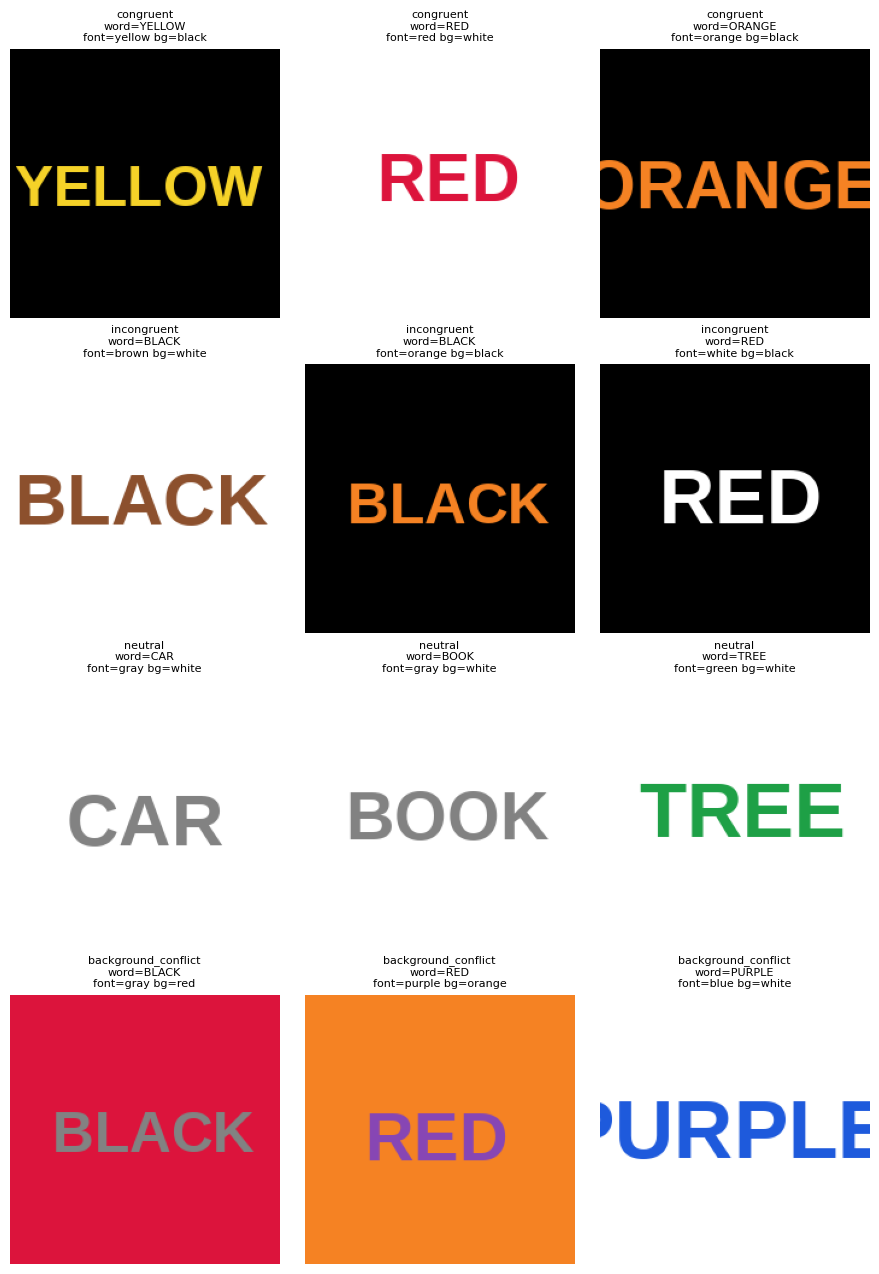

In [7]:
def show_examples(df, n_per_condition=3):
    selected_rows = []
    for condition in CONDITIONS:
        subset = df[df["condition"] == condition]
        selected_rows.extend(subset.sample(n_per_condition, random_state=SEED).to_dict("records"))

    fig, axes = plt.subplots(len(CONDITIONS), n_per_condition, figsize=(3*n_per_condition, 3.2*len(CONDITIONS)))

    for r, condition in enumerate(CONDITIONS):
        condition_rows = [row for row in selected_rows if row["condition"] == condition]
        for c, row in enumerate(condition_rows):
            ax = axes[r, c]
            img = Image.open(row["image_path"]).convert("RGB")
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(
                f"{condition}\nword={row['word']}\nfont={row['font_color']} bg={row['background_color']}",
                fontsize=8
            )

    plt.tight_layout()
    plt.show()

show_examples(df, n_per_condition=3)

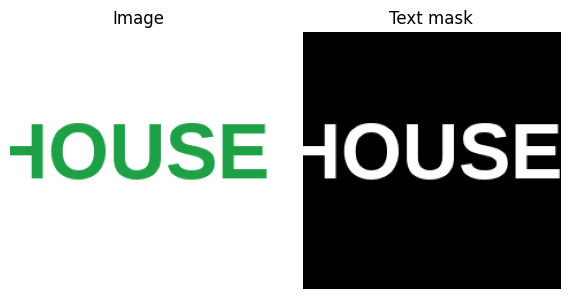

In [8]:
def show_image_and_mask(row):
    img = Image.open(row["image_path"]).convert("RGB")
    mask = Image.open(row["mask_path"]).convert("L")

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(img)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Text mask")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

show_image_and_mask(df.sample(1, random_state=SEED).iloc[0])

# 7. Load CLIP

I use **CLIP ViT-B/16** because it produces a **14 × 14 patch grid**, which is useful for patch-level heatmaps.

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

MODEL_NAME = "ViT-B/16"
model, preprocess = clip.load(MODEL_NAME, device=device, jit=False)
model.eval()

print("Loaded model:", MODEL_NAME)

Device: cuda


100%|████████████████████████████████████████| 335M/335M [00:01<00:00, 196MiB/s]


Loaded model: ViT-B/16


# 8. Black-box testing using one fixed prompt

## What I am doing

I use only one prompt template:

```text
the text is written in {color}
```

For every image, I create 10 candidate prompts:

```text
the text is written in red
the text is written in blue
...
the text is written in white
```

CLIP chooses the color prompt with the highest image-text similarity.

Then I compare the predicted color with the true font color.

In [10]:
candidate_prompts = [PROMPT_TEMPLATE.format(color) for color in COLOR_NAMES]

print("Candidate prompts:")
for prompt in candidate_prompts:
    print("-", prompt)

with torch.no_grad():
    text_tokens = clip.tokenize(candidate_prompts).to(device)
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print("Text features shape:", text_features.shape)

Candidate prompts:
- the text is written in red
- the text is written in blue
- the text is written in green
- the text is written in yellow
- the text is written in orange
- the text is written in purple
- the text is written in brown
- the text is written in gray
- the text is written in black
- the text is written in white
Text features shape: torch.Size([10, 512])


In [11]:
class StroopDatasetForCLIP(Dataset):
    def __init__(self, dataframe, preprocess):
        self.dataframe = dataframe.reset_index(drop=True)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        image_tensor = self.preprocess(image)
        return image_tensor, idx


def categorize_prediction(row):
    pred = row["pred_color"]
    font_color = row["font_color"]
    word_color = row["word_color"]
    background_color = row["background_color"]

    if pred == font_color:
        return "correct_font_color"
    elif isinstance(word_color, str) and len(word_color) > 0 and pred == word_color:
        return "word_bias"
    elif pred == background_color:
        return "background_bias"
    else:
        return "other_error"


def evaluate_clip_blackbox_one_prompt(input_df, batch_size=128):
    eval_df = input_df.reset_index(drop=True).copy()

    dataset = StroopDatasetForCLIP(eval_df, preprocess)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    pred_colors = []
    pred_scores = []

    for images, indices in tqdm(loader, desc="Evaluating CLIP"):
        images = images.to(device)

        with torch.no_grad():
            image_features = model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            similarity = image_features @ text_features.T
            best_scores, best_indices = similarity.max(dim=1)

        for score, pred_idx in zip(best_scores.cpu().numpy(), best_indices.cpu().numpy()):
            pred_colors.append(COLOR_NAMES[int(pred_idx)])
            pred_scores.append(float(score))

    eval_df["pred_color"] = pred_colors
    eval_df["pred_score"] = pred_scores
    eval_df["is_correct"] = eval_df["pred_color"] == eval_df["font_color"]
    eval_df["error_type"] = eval_df.apply(categorize_prediction, axis=1)

    return eval_df

In [12]:
results_df = evaluate_clip_blackbox_one_prompt(df, batch_size=128)

predictions_path = RESULTS_DIR / "blackbox_one_prompt_predictions.csv"
results_df.to_csv(predictions_path, index=False)

print("Saved predictions:", predictions_path)
display(results_df.head())

Evaluating CLIP:   0%|          | 0/157 [00:00<?, ?it/s]

Saved predictions: /content/stroop_clip_one_prompt_dataset/results/blackbox_one_prompt_predictions.csv


,image_id,image_path,mask_path,condition,word,word_color,font_color,background_color,label,correct_prompt,pred_color,pred_score,is_correct,error_type
0,congruent_00000,/content/stroop_clip_one_prompt_dataset/images...,/content/stroop_clip_one_prompt_dataset/masks/...,congruent,BLUE,blue,blue,white,blue,the text is written in blue,blue,0.305420,True,correct_font_color
1,congruent_00001,/content/stroop_clip_one_prompt_dataset/images...,/content/stroop_clip_one_prompt_dataset/masks/...,congruent,YELLOW,yellow,yellow,black,yellow,the text is written in yellow,yellow,0.310303,True,correct_font_color
2,congruent_00002,/content/stroop_clip_one_prompt_dataset/images...,/content/stroop_clip_one_prompt_dataset/masks/...,congruent,BLUE,blue,blue,white,blue,the text is written in blue,blue,0.289062,True,correct_font_color
3,congruent_00003,/content/stroop_clip_one_prompt_dataset/images...,/content/stroop_clip_one_prompt_dataset/masks/...,congruent,BLACK,black,black,white,black,the text is written in black,black,0.292969,True,correct_font_color
4,congruent_00004,/content/stroop_clip_one_prompt_dataset/images...,/content/stroop_clip_one_prompt_dataset/masks/...,congruent,RED,red,red,white,red,the text is written in red,red,0.282959,True,correct_font_color


# 9. Accuracy and error analysis

These are the main results to show the professor.

## Error categories

| Error category | Meaning |
|---|---|
| `correct_font_color` | CLIP predicted the actual font color |
| `word_bias` | CLIP predicted the written word color |
| `background_bias` | CLIP predicted the background color |
| `other_error` | CLIP predicted another color |

In [13]:
overall_accuracy = results_df["is_correct"].mean()

accuracy_by_condition = (
    results_df
    .groupby("condition")["is_correct"]
    .mean()
    .reset_index()
    .rename(columns={"is_correct": "font_color_accuracy"})
)

error_counts = pd.crosstab(results_df["condition"], results_df["error_type"])
error_props = pd.crosstab(results_df["condition"], results_df["error_type"], normalize="index")

print("=" * 80)
print("BLACK-BOX RESULTS USING ONE FIXED PROMPT TEMPLATE")
print("=" * 80)
print("Model:", MODEL_NAME)
print("Prompt template:", PROMPT_TEMPLATE)
print("Dataset size:", len(results_df))
print("Number of classes:", len(COLOR_NAMES))
print(f"Overall font-color accuracy: {overall_accuracy:.4f}")
print("=" * 80)

print("\nAccuracy by condition:")
display(accuracy_by_condition)

print("\nError counts:")
display(error_counts)

print("\nError proportions:")
display(error_props.round(4))

accuracy_by_condition.to_csv(RESULTS_DIR / "accuracy_by_condition.csv", index=False)
error_counts.to_csv(RESULTS_DIR / "error_counts_by_condition.csv")
error_props.to_csv(RESULTS_DIR / "error_proportions_by_condition.csv")

BLACK-BOX RESULTS USING ONE FIXED PROMPT TEMPLATE
Model: ViT-B/16
Prompt template: the text is written in {}
Dataset size: 20000
Number of classes: 10
Overall font-color accuracy: 0.4451

Accuracy by condition:


,condition,font_color_accuracy
0,background_conflict,0.0140
1,congruent,1.0000
2,incongruent,0.0312
3,neutral,0.7354



Error counts:


error_type,background_bias,correct_font_color,other_error,word_bias
condition,,,,
background_conflict,171,70,0,4759
congruent,0,5000,0,0
incongruent,0,156,0,4844
neutral,1295,3677,28,0



Error proportions:


error_type,background_bias,correct_font_color,other_error,word_bias
condition,,,,
background_conflict,0.0342,0.0140,0.0000,0.9518
congruent,0.0000,1.0000,0.0000,0.0000
incongruent,0.0000,0.0312,0.0000,0.9688
neutral,0.2590,0.7354,0.0056,0.0000


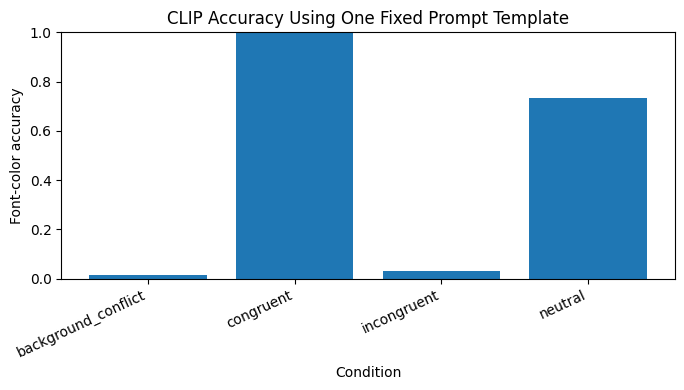

In [14]:
plt.figure(figsize=(7, 4))
plt.bar(accuracy_by_condition["condition"], accuracy_by_condition["font_color_accuracy"])
plt.ylim(0, 1)
plt.ylabel("Font-color accuracy")
plt.xlabel("Condition")
plt.title("CLIP Accuracy Using One Fixed Prompt Template")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "accuracy_by_condition.png", dpi=200)
plt.show()

# 10. White-box testing using one attribution prompt

For each selected image, I generate a heatmap using only **one attribution prompt**.

That prompt corresponds to the model's own predicted color:

```text
the text is written in {predicted_color}
```

### Example

If the image is:

```text
word = ORANGE
font color = yellow
background = red
CLIP prediction = orange
```

then the attribution prompt is:

```text
the text is written in orange
```

This heatmap answers:

> Which image patches supported CLIP's actual prediction?

In [15]:
class CLIPPatchGradCAM:
    def __init__(self, model):
        self.model = model
        self.activations = None
        self.gradients = None
        self.hook_handle = None

        # In CLIP ViT, conv1 creates the patch embeddings.
        self.target_layer = self.model.visual.conv1
        self._register_hook()

    def _register_hook(self):
        def forward_hook(module, input_tensor, output_tensor):
            self.activations = output_tensor

            def save_gradient(gradient):
                self.gradients = gradient

            output_tensor.register_hook(save_gradient)

        self.hook_handle = self.target_layer.register_forward_hook(forward_hook)

    def remove_hook(self):
        if self.hook_handle is not None:
            self.hook_handle.remove()

    def generate(self, image_path, prompt):
        self.model.zero_grad(set_to_none=True)
        self.activations = None
        self.gradients = None

        image = Image.open(image_path).convert("RGB")
        image_input = preprocess(image).unsqueeze(0).to(device)
        text_input = clip.tokenize([prompt]).to(device)

        image_features = self.model.encode_image(image_input)
        text_features = self.model.encode_text(text_input)

        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        score = (image_features * text_features).sum()
        score.backward()

        acts = self.activations.detach()
        grads = self.gradients.detach()

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1).squeeze(0)

        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.cpu().numpy(), float(score.detach().cpu().item())


gradcam = CLIPPatchGradCAM(model)

In [16]:
def upsample_cam(cam, size=224):
    cam_uint8 = (cam * 255).astype(np.uint8)
    cam_img = Image.fromarray(cam_uint8).resize((size, size), resample=Image.BILINEAR)
    return np.array(cam_img).astype(np.float32) / 255.0


def compute_text_focus_metrics(cam, mask_path):
    cam_full = upsample_cam(cam, IMAGE_SIZE)

    mask = Image.open(mask_path).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
    mask_np = np.array(mask)

    text_mask = mask_np > 127
    background_mask = ~text_mask

    total_energy = cam_full.sum() + 1e-8

    text_energy_share = cam_full[text_mask].sum() / total_energy
    background_energy_share = cam_full[background_mask].sum() / total_energy
    text_area_share = text_mask.mean()

    text_enrichment = text_energy_share / (text_area_share + 1e-8)

    return {
        "text_energy_share": float(text_energy_share),
        "background_energy_share": float(background_energy_share),
        "text_area_share": float(text_area_share),
        "text_enrichment": float(text_enrichment),
    }


def visualize_one_prompt_heatmap(row, save_dir=HEATMAP_DIR):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    predicted_color = row["pred_color"]
    attribution_prompt = PROMPT_TEMPLATE.format(predicted_color)

    cam, score = gradcam.generate(row["image_path"], attribution_prompt)
    metrics = compute_text_focus_metrics(cam, row["mask_path"])

    image = Image.open(row["image_path"]).convert("RGB")
    cam_full = upsample_cam(cam, IMAGE_SIZE)

    fig, axes = plt.subplots(1, 3, figsize=(11, 4))

    axes[0].imshow(image)
    axes[0].set_title("Original image")
    axes[0].axis("off")

    axes[1].imshow(cam_full, cmap="jet")
    axes[1].set_title("Heatmap")
    axes[1].axis("off")

    axes[2].imshow(image)
    axes[2].imshow(cam_full, cmap="jet", alpha=0.45)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    title = (
        f"Condition: {row['condition']} | Error: {row['error_type']}\n"
        f"Word: {row['word']} | Font: {row['font_color']} | Background: {row['background_color']} | Prediction: {row['pred_color']}\n"
        f"Attribution prompt: {attribution_prompt} | Score: {score:.4f} | Text enrichment: {metrics['text_enrichment']:.2f}"
    )

    fig.suptitle(title, fontsize=9)
    plt.tight_layout()

    output_path = save_dir / f"{row['image_id']}_one_prompt_heatmap.png"
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

    output_record = {
        "image_id": row["image_id"],
        "condition": row["condition"],
        "word": row["word"],
        "font_color": row["font_color"],
        "background_color": row["background_color"],
        "pred_color": row["pred_color"],
        "error_type": row["error_type"],
        "attribution_prompt": attribution_prompt,
        "similarity_score": score,
        "heatmap_path": str(output_path),
    }

    output_record.update(metrics)
    return output_record

# 11. Generate heatmaps for important word-bias examples

These examples are useful because they show the Stroop-style failure.

The model predicts the written word color instead of the real font color.

In [17]:
word_bias_examples = results_df[
    (results_df["error_type"] == "word_bias") &
    (results_df["condition"].isin(["incongruent", "background_conflict"]))
].copy()

print("Number of conflict word-bias examples:", len(word_bias_examples))

selected_word_bias = word_bias_examples.sample(
    n=min(5, len(word_bias_examples)),
    random_state=SEED
).reset_index(drop=True)

display(selected_word_bias[[
    "image_id", "condition", "word", "font_color",
    "background_color", "pred_color", "error_type"
]])

Number of conflict word-bias examples: 9603


,image_id,condition,word,font_color,background_color,pred_color,error_type
0,incongruent_01368,incongruent,YELLOW,green,white,yellow,word_bias
1,background_conflict_04900,background_conflict,BLACK,white,gray,black,word_bias
2,background_conflict_02507,background_conflict,RED,white,brown,red,word_bias
3,background_conflict_00569,background_conflict,YELLOW,green,black,yellow,word_bias
4,background_conflict_01723,background_conflict,GREEN,gray,orange,green,word_bias


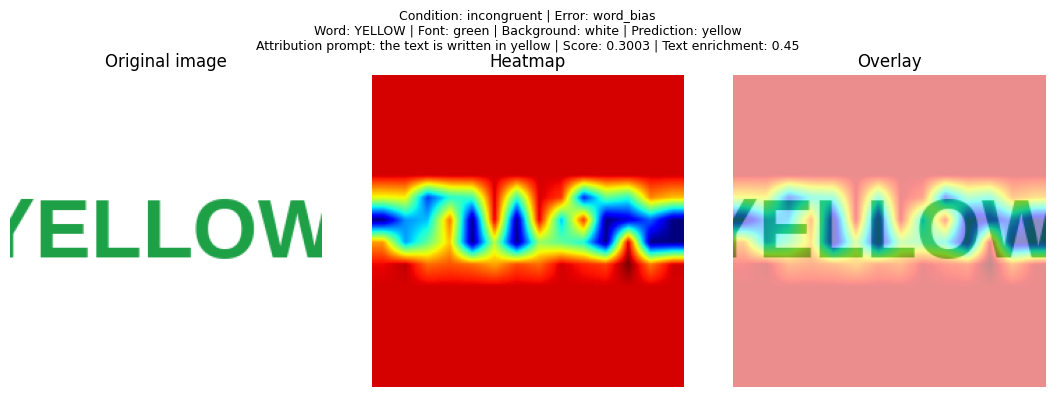

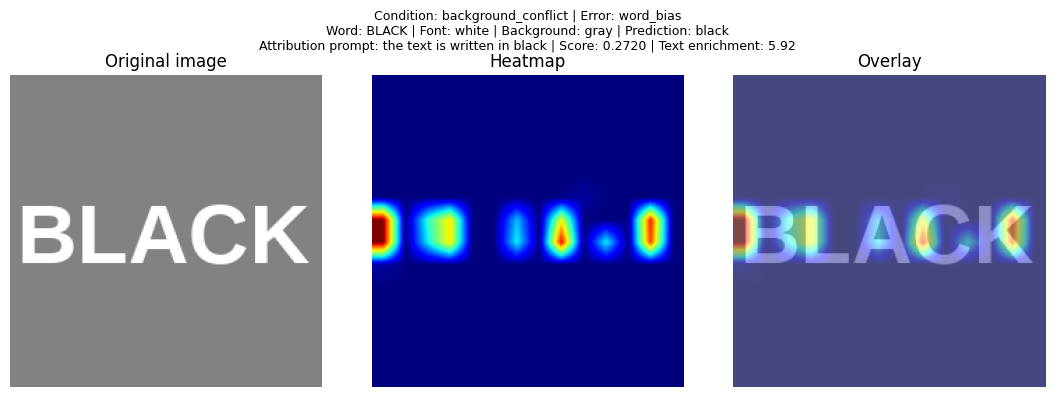

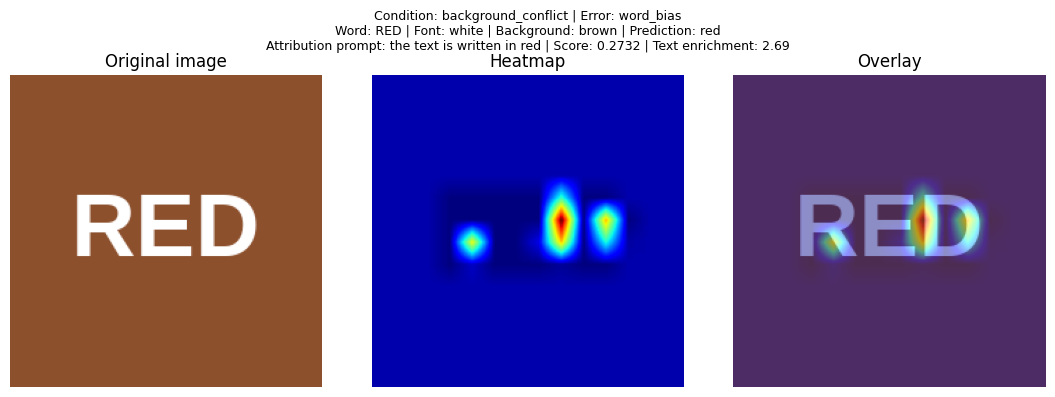

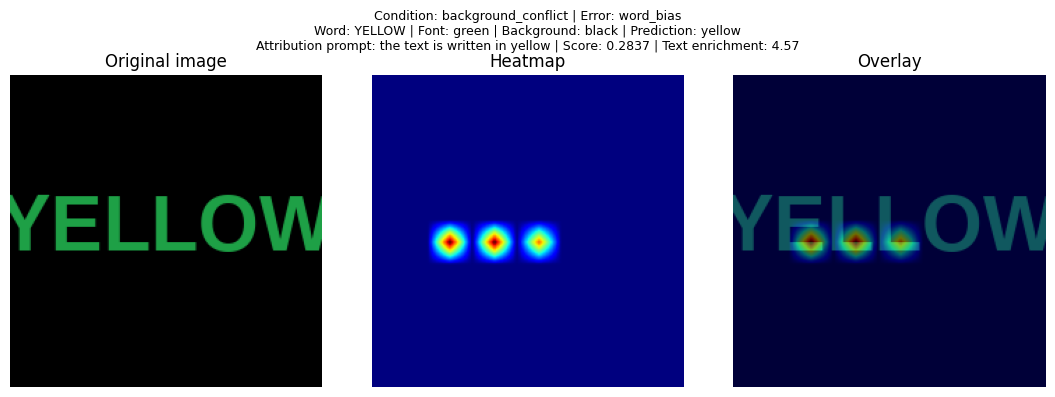

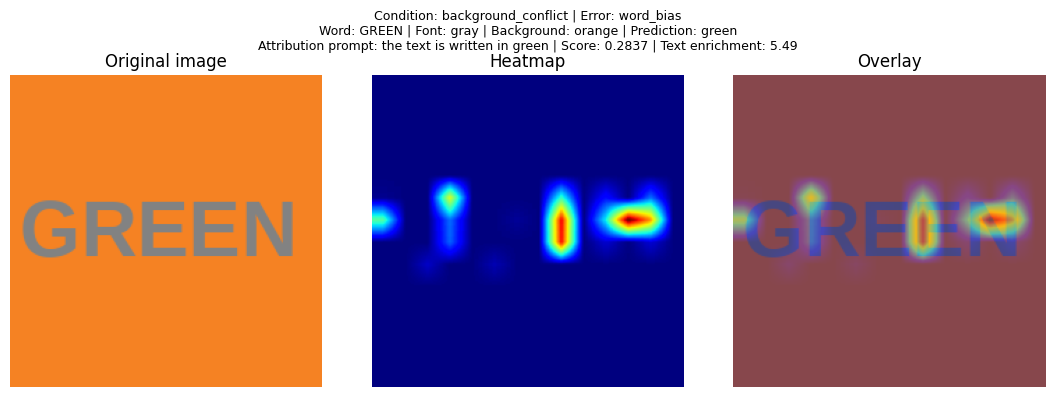

Saved heatmap metrics: /content/stroop_clip_one_prompt_dataset/results/one_prompt_heatmap_metrics_word_bias.csv


,image_id,condition,word,font_color,background_color,pred_color,error_type,attribution_prompt,similarity_score,heatmap_path,text_energy_share,background_energy_share,text_area_share,text_enrichment
0,incongruent_01368,incongruent,YELLOW,green,white,yellow,word_bias,the text is written in yellow,0.300293,/content/stroop_clip_one_prompt_dataset/result...,0.035603,0.964396,0.079381,0.448516
1,background_conflict_04900,background_conflict,BLACK,white,gray,black,word_bias,the text is written in black,0.271973,/content/stroop_clip_one_prompt_dataset/result...,0.449262,0.550738,0.075953,5.915020
2,background_conflict_02507,background_conflict,RED,white,brown,red,word_bias,the text is written in red,0.273193,/content/stroop_clip_one_prompt_dataset/result...,0.163592,0.836408,0.060886,2.686866
3,background_conflict_00569,background_conflict,YELLOW,green,black,yellow,word_bias,the text is written in yellow,0.283691,/content/stroop_clip_one_prompt_dataset/result...,0.337168,0.662832,0.073820,4.567418
4,background_conflict_01723,background_conflict,GREEN,gray,orange,green,word_bias,the text is written in green,0.283691,/content/stroop_clip_one_prompt_dataset/result...,0.412611,0.587389,0.075195,5.487189


In [18]:
heatmap_records = []

for _, row in selected_word_bias.iterrows():
    record = visualize_one_prompt_heatmap(row, save_dir=HEATMAP_DIR)
    heatmap_records.append(record)

heatmap_df = pd.DataFrame(heatmap_records)
heatmap_metrics_path = RESULTS_DIR / "one_prompt_heatmap_metrics_word_bias.csv"
heatmap_df.to_csv(heatmap_metrics_path, index=False)

print("Saved heatmap metrics:", heatmap_metrics_path)
display(heatmap_df)

# 12. Generate one heatmap from each condition

This gives a clean visual set for presentation.

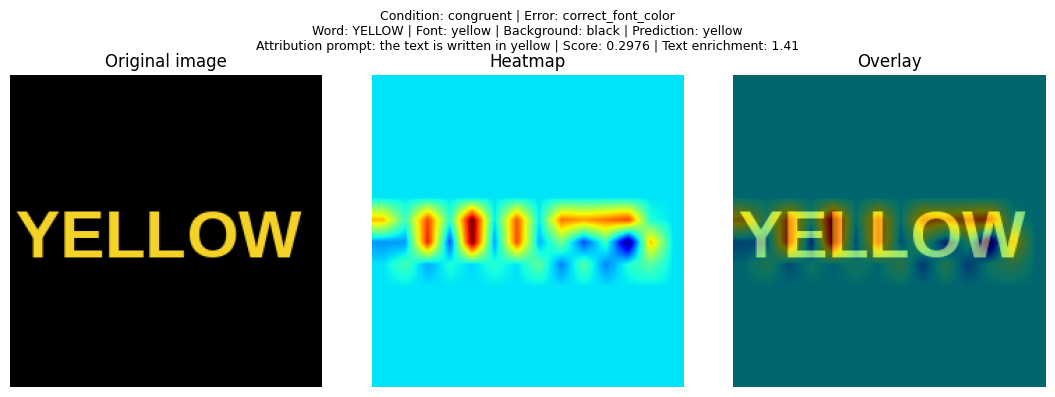

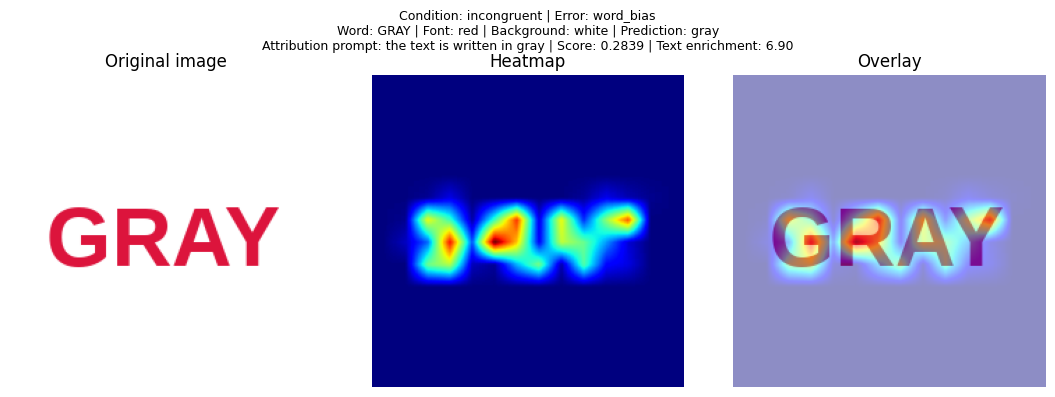

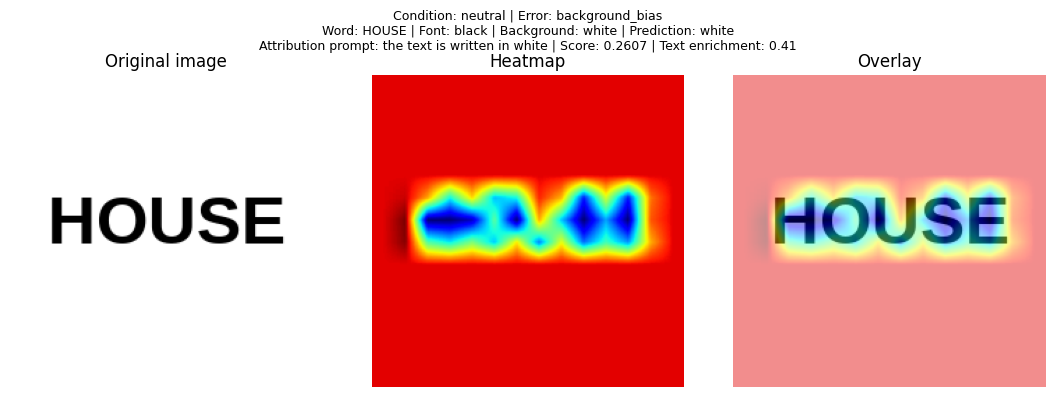

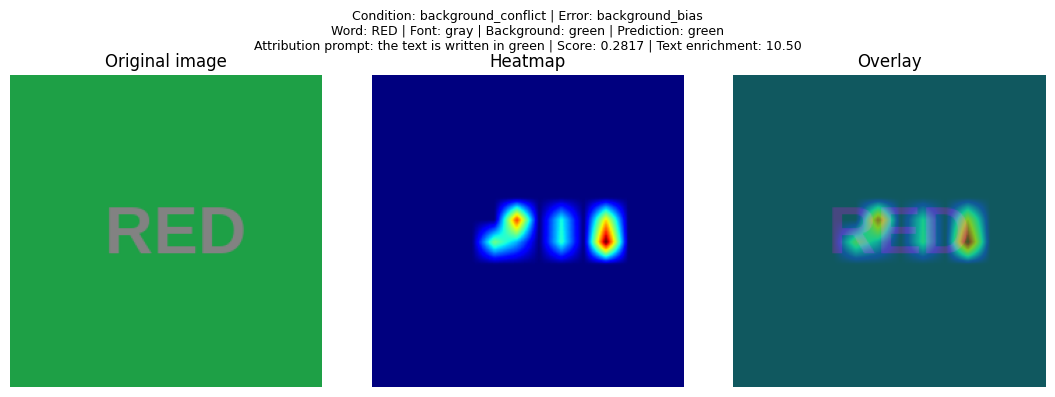

Saved condition heatmap metrics: /content/stroop_clip_one_prompt_dataset/results/one_prompt_heatmap_metrics_by_condition.csv


,image_id,condition,word,font_color,background_color,pred_color,error_type,attribution_prompt,similarity_score,heatmap_path,text_energy_share,background_energy_share,text_area_share,text_enrichment
0,congruent_01501,congruent,YELLOW,yellow,black,yellow,correct_font_color,the text is written in yellow,0.297607,/content/stroop_clip_one_prompt_dataset/result...,0.078308,0.921691,0.055525,1.410339
1,incongruent_04079,incongruent,GRAY,red,white,gray,word_bias,the text is written in gray,0.283936,/content/stroop_clip_one_prompt_dataset/result...,0.427413,0.572587,0.061962,6.898001
2,neutral_02808,neutral,HOUSE,black,white,white,background_bias,the text is written in white,0.260742,/content/stroop_clip_one_prompt_dataset/result...,0.020736,0.979263,0.050403,0.411417
3,background_conflict_02864,background_conflict,RED,gray,green,green,background_bias,the text is written in green,0.281738,/content/stroop_clip_one_prompt_dataset/result...,0.347145,0.652855,0.033064,10.499313


In [19]:
condition_records = []

for condition in CONDITIONS:
    subset = results_df[results_df["condition"] == condition].copy()

    # Prefer an error example if available, because it is more interesting for explanation.
    errors = subset[subset["error_type"] != "correct_font_color"]
    if len(errors) > 0:
        row = errors.sample(1, random_state=SEED).iloc[0]
    else:
        row = subset.sample(1, random_state=SEED).iloc[0]

    record = visualize_one_prompt_heatmap(row, save_dir=RESULTS_DIR / "heatmaps_by_condition")
    condition_records.append(record)

condition_heatmap_df = pd.DataFrame(condition_records)
condition_heatmap_path = RESULTS_DIR / "one_prompt_heatmap_metrics_by_condition.csv"
condition_heatmap_df.to_csv(condition_heatmap_path, index=False)

print("Saved condition heatmap metrics:", condition_heatmap_path)
display(condition_heatmap_df)

# 13. Layer-Wise White-Box Analysis Using One Prompt

In the previous white-box section, I generated one heatmap using the model's predicted prompt:

```text
the text is written in {predicted_color}

In [20]:
class CLIPViTLayerAttribution:
    """
    Layer-wise attribution for CLIP ViT visual transformer.

    This class hooks selected transformer blocks inside CLIP's visual encoder.

    For ViT-B/16:
    - Input image size = 224 x 224
    - Patch size = 16 x 16
    - Patch grid = 14 x 14

    The final heatmap for each layer shows which image patches contributed
    to the image-text similarity score for one prompt.
    """

    def __init__(self, model, layers=None):
        self.model = model

        # Total number of visual transformer layers in CLIP ViT
        num_layers = len(self.model.visual.transformer.resblocks)

        # Default selected layers
        if layers is None:
            layers = [0, 3, 6, 9]

        # Keep only valid layer numbers
        self.layers = [layer for layer in layers if layer < num_layers]

        self.activations = {}
        self.gradients = {}
        self.hook_handles = []

        self._register_hooks()

        print("Total CLIP visual transformer layers:", num_layers)
        print("Selected layers for analysis:", self.layers)

    def _register_hooks(self):
        """
        Register forward hooks on selected transformer blocks.

        The hook stores:
        - activations from that layer
        - gradients during backpropagation
        """

        for layer_idx in self.layers:
            block = self.model.visual.transformer.resblocks[layer_idx]

            def make_hook(idx):
                def forward_hook(module, input_tensor, output_tensor):
                    # Some modules may return a tuple, so handle that safely
                    if isinstance(output_tensor, tuple):
                        output_tensor = output_tensor[0]

                    # Save activation
                    self.activations[idx] = output_tensor

                    # Save gradient during backward pass
                    def save_gradient(grad):
                        self.gradients[idx] = grad

                    output_tensor.register_hook(save_gradient)

                return forward_hook

            handle = block.register_forward_hook(make_hook(layer_idx))
            self.hook_handles.append(handle)

    def remove_hooks(self):
        """
        Remove hooks if needed.
        """
        for handle in self.hook_handles:
            handle.remove()

    def _tokens_to_cam(self, activation, gradient, mode="absolute"):
        """
        Convert token-level relevance into a 2D patch heatmap.

        CLIP ViT usually uses this shape:
        [sequence_length, batch_size, hidden_dim]

        The first token is the CLS token.
        The remaining tokens are image patch tokens.

        For ViT-B/16:
        196 patch tokens = 14 x 14 heatmap.
        """

        # Case 1: [seq_len, batch, dim]
        if activation.dim() == 3 and activation.shape[1] == 1:
            patch_acts = activation[1:, 0, :]
            patch_grads = gradient[1:, 0, :]

        # Case 2: [batch, seq_len, dim]
        elif activation.dim() == 3 and activation.shape[0] == 1:
            patch_acts = activation[0, 1:, :]
            patch_grads = gradient[0, 1:, :]

        else:
            raise ValueError(f"Unexpected activation shape: {activation.shape}")

        # Compute relevance per patch token
        if mode == "positive":
            relevance = (patch_acts * patch_grads).sum(dim=-1)
            relevance = torch.relu(relevance)

        elif mode == "absolute":
            # Absolute mode avoids blank maps when positive-only gradients vanish
            relevance = (patch_acts * patch_grads).sum(dim=-1).abs()

        elif mode == "signed":
            relevance = (patch_acts * patch_grads).sum(dim=-1)

        else:
            raise ValueError("mode must be 'positive', 'absolute', or 'signed'")

        # Convert token list into 2D square grid
        num_patches = relevance.shape[0]
        grid_size = int(np.sqrt(num_patches))

        # Safety check
        relevance = relevance[:grid_size * grid_size]

        cam = relevance.reshape(grid_size, grid_size)

        # Normalize between 0 and 1
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.detach().cpu().numpy()

    def generate(self, image_path, prompt, mode="absolute"):
        """
        Generate layer-wise heatmaps for one image and one prompt.

        The prompt should be:

        the text is written in {predicted_color}

        This explains the model's actual prediction.
        """

        self.model.zero_grad(set_to_none=True)
        self.activations = {}
        self.gradients = {}

        image = Image.open(image_path).convert("RGB")
        image_input = preprocess(image).unsqueeze(0).to(device)

        text_input = clip.tokenize([prompt]).to(device)

        # Forward pass
        image_features = self.model.encode_image(image_input)
        text_features = self.model.encode_text(text_input)

        # Normalize image and text embeddings
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # CLIP image-text similarity score
        score = (image_features * text_features).sum()

        # Backward pass
        score.backward()

        layer_cams = {}

        for layer_idx in self.layers:
            activation = self.activations[layer_idx].detach()
            gradient = self.gradients[layer_idx].detach()

            cam = self._tokens_to_cam(
                activation=activation,
                gradient=gradient,
                mode=mode
            )

            layer_cams[layer_idx] = cam

        return layer_cams, float(score.detach().cpu().item())


# Create layer-wise attribution object
layerwise_attributor = CLIPViTLayerAttribution(
    model=model,
    layers=[0, 3, 6, 9]
)

Total CLIP visual transformer layers: 12
Selected layers for analysis: [0, 3, 6, 9]


# 14. Visualize Layer-Wise Heatmaps for One Image

This function takes one row from the prediction results and generates layer-wise heatmaps.

The attribution prompt is created from the model's predicted color:

```text
the text is written in {predicted_color}

In [21]:
def visualize_layerwise_one_prompt(row, mode="absolute", save_dir=RESULTS_DIR / "layerwise_heatmaps"):
    """
    Generate layer-wise heatmaps using one attribution prompt.

    The one prompt is:

    the text is written in {predicted_color}

    This explains CLIP's actual prediction across different visual transformer layers.
    """

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    predicted_color = row["pred_color"]
    attribution_prompt = PROMPT_TEMPLATE.format(predicted_color)

    # Generate one heatmap per selected transformer layer
    layer_cams, score = layerwise_attributor.generate(
        image_path=row["image_path"],
        prompt=attribution_prompt,
        mode=mode
    )

    image = Image.open(row["image_path"]).convert("RGB")

    num_layers = len(layer_cams)

    fig, axes = plt.subplots(
        1,
        num_layers + 1,
        figsize=(3.2 * (num_layers + 1), 3.8)
    )

    # Original image
    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[0].axis("off")

    records = []

    # Plot heatmap overlay for each layer
    for i, (layer_idx, cam) in enumerate(layer_cams.items(), start=1):
        cam_full = upsample_cam(cam, IMAGE_SIZE)

        axes[i].imshow(image)
        axes[i].imshow(cam_full, cmap="jet", alpha=0.45)
        axes[i].set_title(f"Layer {layer_idx}")
        axes[i].axis("off")

        # Compute text-region focus metrics
        metrics = compute_text_focus_metrics(cam, row["mask_path"])

        record = {
            "image_id": row["image_id"],
            "condition": row["condition"],
            "word": row["word"],
            "font_color": row["font_color"],
            "background_color": row["background_color"],
            "pred_color": row["pred_color"],
            "error_type": row["error_type"],
            "attribution_prompt": attribution_prompt,
            "layer": layer_idx,
            "similarity_score": score,
            "mode": mode,
        }

        record.update(metrics)
        records.append(record)

    title = (
        f"Layer-wise one-prompt attribution\n"
        f"Condition: {row['condition']} | Error: {row['error_type']}\n"
        f"Word: {row['word']} | Font color: {row['font_color']} | "
        f"Background: {row['background_color']} | Prediction: {row['pred_color']}\n"
        f"Prompt: '{attribution_prompt}' | Similarity: {score:.4f}"
    )

    fig.suptitle(title, fontsize=10)
    plt.tight_layout()

    output_path = save_dir / f"{row['image_id']}_layerwise_one_prompt.png"
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

    return records, str(output_path)

# 15. Select Word-Bias Examples for Layer-Wise Analysis

For the main Stroop-style explanation, the most important cases are `word_bias` examples.

A `word_bias` example means:

```text
CLIP prediction = written word color
Correct answer = actual font color

In [22]:
# Select word-bias examples from conflict conditions
layerwise_examples = results_df[
    (results_df["error_type"] == "word_bias") &
    (results_df["condition"].isin(["incongruent", "background_conflict"]))
].copy()

print("Number of conflict word-bias examples:", len(layerwise_examples))

# Select a few examples for visualization
selected_layerwise_examples = layerwise_examples.sample(
    n=min(3, len(layerwise_examples)),
    random_state=SEED
).reset_index(drop=True)

display(selected_layerwise_examples[[
    "image_id",
    "condition",
    "word",
    "font_color",
    "background_color",
    "pred_color",
    "error_type"
]])

Number of conflict word-bias examples: 9603


,image_id,condition,word,font_color,background_color,pred_color,error_type
0,incongruent_01368,incongruent,YELLOW,green,white,yellow,word_bias
1,background_conflict_04900,background_conflict,BLACK,white,gray,black,word_bias
2,background_conflict_02507,background_conflict,RED,white,brown,red,word_bias


# 16. Generate Layer-Wise Heatmaps

This cell generates layer-wise heatmaps for selected word-bias examples.

Each selected image will show:

```text
Original image | Layer 0 | Layer 3 | Layer 6 | Layer 9

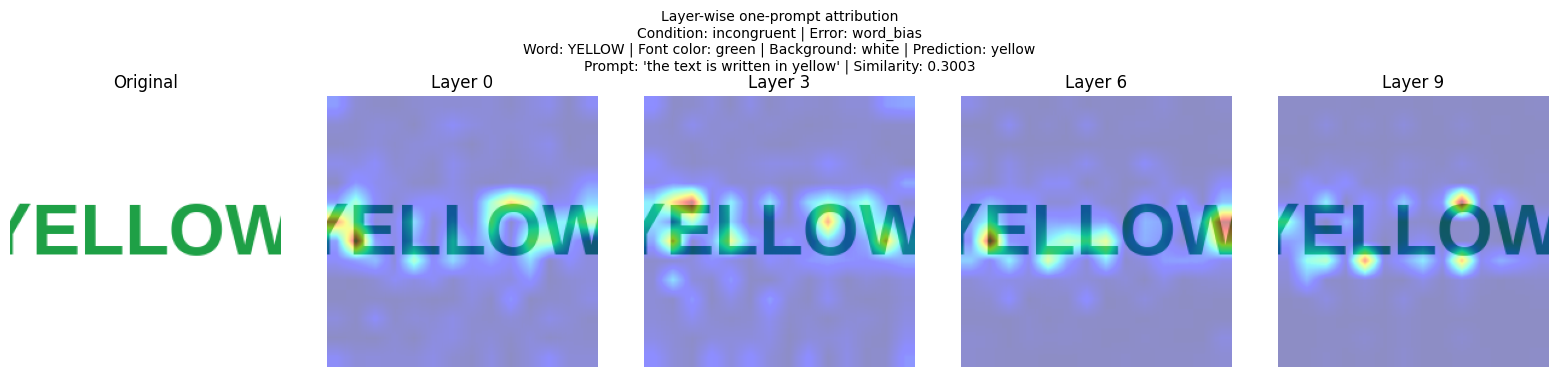

Saved layer-wise heatmap: /content/stroop_clip_one_prompt_dataset/results/layerwise_heatmaps/incongruent_01368_layerwise_one_prompt.png


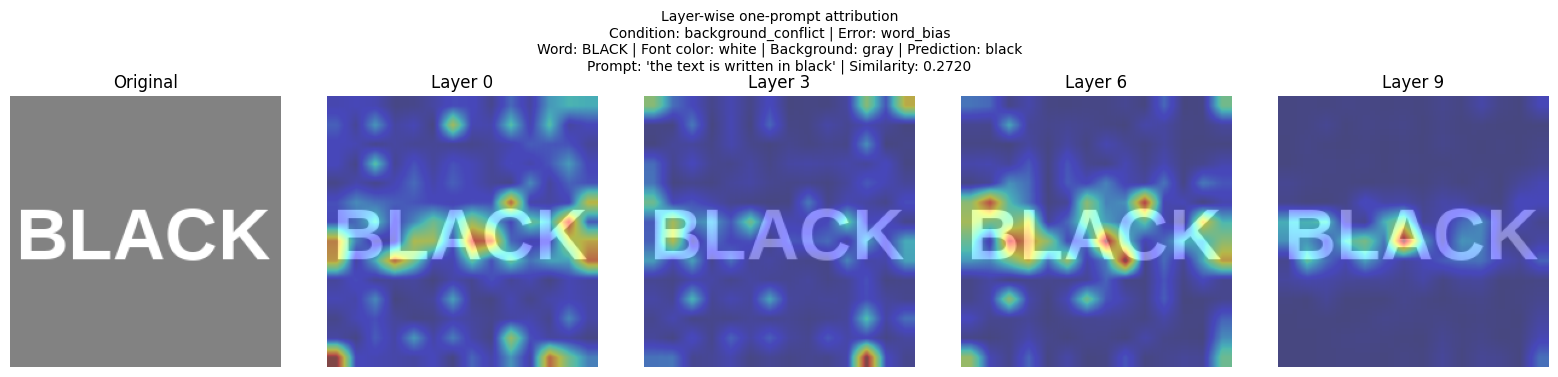

Saved layer-wise heatmap: /content/stroop_clip_one_prompt_dataset/results/layerwise_heatmaps/background_conflict_04900_layerwise_one_prompt.png


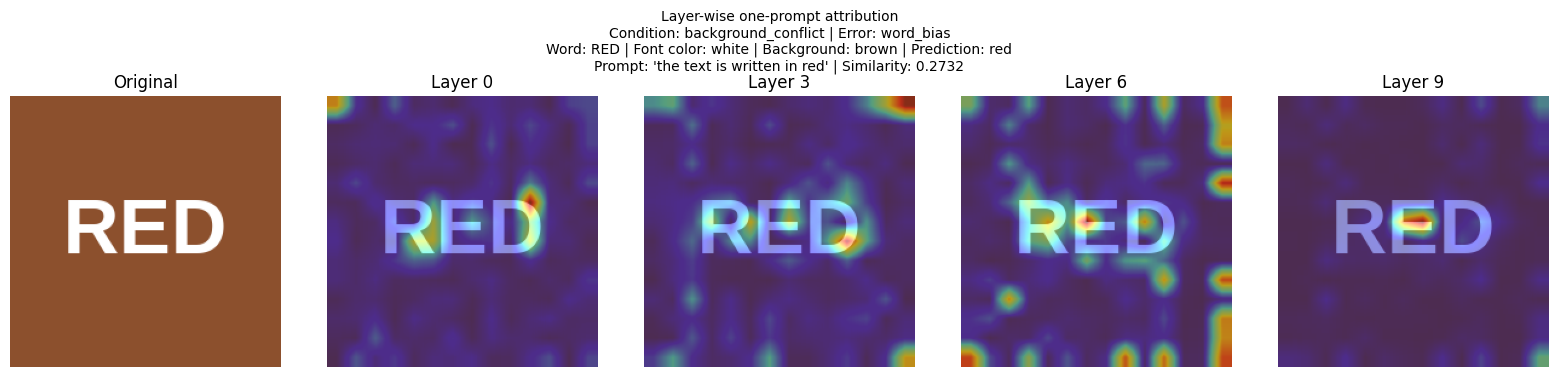

Saved layer-wise heatmap: /content/stroop_clip_one_prompt_dataset/results/layerwise_heatmaps/background_conflict_02507_layerwise_one_prompt.png
Saved layer-wise metrics: /content/stroop_clip_one_prompt_dataset/results/layerwise_one_prompt_metrics.csv


,image_id,condition,word,font_color,background_color,pred_color,error_type,attribution_prompt,layer,similarity_score,mode,text_energy_share,background_energy_share,text_area_share,text_enrichment
0,incongruent_01368,incongruent,YELLOW,green,white,yellow,word_bias,the text is written in yellow,0,0.300293,absolute,0.243056,0.756944,0.079381,3.061911
1,incongruent_01368,incongruent,YELLOW,green,white,yellow,word_bias,the text is written in yellow,3,0.300293,absolute,0.221981,0.778019,0.079381,2.796418
2,incongruent_01368,incongruent,YELLOW,green,white,yellow,word_bias,the text is written in yellow,6,0.300293,absolute,0.276569,0.723431,0.079381,3.484084
3,incongruent_01368,incongruent,YELLOW,green,white,yellow,word_bias,the text is written in yellow,9,0.300293,absolute,0.210274,0.789726,0.079381,2.648938
4,background_conflict_04900,background_conflict,BLACK,white,gray,black,word_bias,the text is written in black,0,0.271973,absolute,0.145234,0.854766,0.075953,1.912159
5,background_conflict_04900,background_conflict,BLACK,white,gray,black,word_bias,the text is written in black,3,0.271973,absolute,0.129193,0.870807,0.075953,1.700967
6,background_conflict_04900,background_conflict,BLACK,white,gray,black,word_bias,the text is written in black,6,0.271973,absolute,0.198627,0.801373,0.075953,2.615143
7,background_conflict_04900,background_conflict,BLACK,white,gray,black,word_bias,the text is written in black,9,0.271973,absolute,0.281580,0.718420,0.075953,3.707312
8,background_conflict_02507,background_conflict,RED,white,brown,red,word_bias,the text is written in red,0,0.273193,absolute,0.138647,0.861353,0.060886,2.277173
9,background_conflict_02507,background_conflict,RED,white,brown,red,word_bias,the text is written in red,3,0.273193,absolute,0.126641,0.873359,0.060886,2.079980


In [23]:
all_layerwise_records = []

for _, row in selected_layerwise_examples.iterrows():
    records, output_path = visualize_layerwise_one_prompt(
        row=row,
        mode="absolute",
        save_dir=RESULTS_DIR / "layerwise_heatmaps"
    )

    all_layerwise_records.extend(records)

    print("Saved layer-wise heatmap:", output_path)

layerwise_df = pd.DataFrame(all_layerwise_records)

layerwise_metrics_path = RESULTS_DIR / "layerwise_one_prompt_metrics.csv"
layerwise_df.to_csv(layerwise_metrics_path, index=False)

print("Saved layer-wise metrics:", layerwise_metrics_path)
display(layerwise_df)

# 17. Aggregate Layer-Wise Analysis

Now I calculate layer-wise statistics across multiple examples.

The main metric is:

```text
text_enrichment

In [24]:
def sample_group_for_layerwise(results_df, condition, error_type, n=5):
    """
    Select examples from a specific condition and error type.
    """

    subset = results_df[
        (results_df["condition"] == condition) &
        (results_df["error_type"] == error_type)
    ].copy()

    if len(subset) == 0:
        print(f"No examples found for condition={condition}, error_type={error_type}")
        return pd.DataFrame()

    return subset.sample(
        n=min(n, len(subset)),
        random_state=SEED
    )


# Groups to analyze
groups_to_test = [
    ("background_conflict", "word_bias"),
    ("incongruent", "word_bias"),
    ("neutral", "correct_font_color"),
    ("congruent", "correct_font_color"),
]

aggregate_records = []

for condition, error_type in groups_to_test:
    group_df = sample_group_for_layerwise(
        results_df=results_df,
        condition=condition,
        error_type=error_type,
        n=5
    )

    print("\nRunning layer-wise attribution for group:")
    print("Condition:", condition)
    print("Error type:", error_type)
    print("Number of examples:", len(group_df))

    for _, row in tqdm(group_df.iterrows(), total=len(group_df)):
        predicted_color = row["pred_color"]

        # One attribution prompt based on predicted label
        attribution_prompt = PROMPT_TEMPLATE.format(predicted_color)

        layer_cams, score = layerwise_attributor.generate(
            image_path=row["image_path"],
            prompt=attribution_prompt,
            mode="absolute"
        )

        for layer_idx, cam in layer_cams.items():
            metrics = compute_text_focus_metrics(cam, row["mask_path"])

            record = {
                "group": f"{condition}__{error_type}",
                "image_id": row["image_id"],
                "condition": condition,
                "error_type": error_type,
                "word": row["word"],
                "font_color": row["font_color"],
                "background_color": row["background_color"],
                "pred_color": row["pred_color"],
                "attribution_prompt": attribution_prompt,
                "layer": layer_idx,
                "similarity_score": score,
            }

            record.update(metrics)
            aggregate_records.append(record)

aggregate_layerwise_df = pd.DataFrame(aggregate_records)

aggregate_layerwise_path = RESULTS_DIR / "aggregate_layerwise_one_prompt_metrics.csv"
aggregate_layerwise_df.to_csv(aggregate_layerwise_path, index=False)

print("Saved aggregate layer-wise metrics:", aggregate_layerwise_path)
display(aggregate_layerwise_df.head())


Running layer-wise attribution for group:
Condition: background_conflict
Error type: word_bias
Number of examples: 5


  0%|          | 0/5 [00:00<?, ?it/s]


Running layer-wise attribution for group:
Condition: incongruent
Error type: word_bias
Number of examples: 5


  0%|          | 0/5 [00:00<?, ?it/s]


Running layer-wise attribution for group:
Condition: neutral
Error type: correct_font_color
Number of examples: 5


  0%|          | 0/5 [00:00<?, ?it/s]


Running layer-wise attribution for group:
Condition: congruent
Error type: correct_font_color
Number of examples: 5


  0%|          | 0/5 [00:00<?, ?it/s]

Saved aggregate layer-wise metrics: /content/stroop_clip_one_prompt_dataset/results/aggregate_layerwise_one_prompt_metrics.csv


,group,image_id,condition,error_type,word,font_color,background_color,pred_color,attribution_prompt,layer,similarity_score,text_energy_share,background_energy_share,text_area_share,text_enrichment
0,background_conflict__word_bias,background_conflict_02437,background_conflict,word_bias,BLUE,orange,brown,blue,the text is written in blue,0,0.282959,0.131619,0.868381,0.053532,2.458724
1,background_conflict__word_bias,background_conflict_02437,background_conflict,word_bias,BLUE,orange,brown,blue,the text is written in blue,3,0.282959,0.169819,0.830181,0.053532,3.172317
2,background_conflict__word_bias,background_conflict_02437,background_conflict,word_bias,BLUE,orange,brown,blue,the text is written in blue,6,0.282959,0.146904,0.853096,0.053532,2.744250
3,background_conflict__word_bias,background_conflict_02437,background_conflict,word_bias,BLUE,orange,brown,blue,the text is written in blue,9,0.282959,0.221173,0.778827,0.053532,4.131644
4,background_conflict__word_bias,background_conflict_00330,background_conflict,word_bias,YELLOW,white,black,yellow,the text is written in yellow,0,0.295166,0.220511,0.779489,0.083008,2.656506


# 18. Layer-Wise Summary Table

This table summarizes the average text-region focus at each layer.

Important columns:

| Column | Meaning |
|---|---|
| `mean_similarity_score` | Average CLIP image-text similarity for the attribution prompt |
| `mean_text_energy_share` | Average heatmap energy on text pixels |
| `mean_background_energy_share` | Average heatmap energy on background pixels |
| `mean_text_area_share` | How much image area is text |
| `mean_text_enrichment` | Text focus normalized by text area |

The most important metric is:

```text
mean_text_enrichment

In [25]:
layerwise_summary = (
    aggregate_layerwise_df
    .groupby(["group", "layer"])
    .agg(
        mean_similarity_score=("similarity_score", "mean"),
        mean_text_energy_share=("text_energy_share", "mean"),
        mean_background_energy_share=("background_energy_share", "mean"),
        mean_text_area_share=("text_area_share", "mean"),
        mean_text_enrichment=("text_enrichment", "mean"),
    )
    .reset_index()
)

summary_path = RESULTS_DIR / "layerwise_one_prompt_summary.csv"
layerwise_summary.to_csv(summary_path, index=False)

print("Saved layer-wise summary:", summary_path)
display(layerwise_summary)

Saved layer-wise summary: /content/stroop_clip_one_prompt_dataset/results/layerwise_one_prompt_summary.csv


,group,layer,mean_similarity_score,mean_text_energy_share,mean_background_energy_share,mean_text_area_share,mean_text_enrichment
0,background_conflict__word_bias,0,0.286816,0.153543,0.846457,0.064533,2.289392
1,background_conflict__word_bias,3,0.286816,0.178748,0.821252,0.064533,2.778517
2,background_conflict__word_bias,6,0.286816,0.211130,0.788870,0.064533,3.225264
3,background_conflict__word_bias,9,0.286816,0.223640,0.776360,0.064533,3.687696
4,congruent__correct_font_color,0,0.303369,0.143662,0.856338,0.063911,2.216367
5,congruent__correct_font_color,3,0.303369,0.187189,0.812811,0.063911,2.876537
6,congruent__correct_font_color,6,0.303369,0.212635,0.787365,0.063911,3.301562
7,congruent__correct_font_color,9,0.303369,0.267129,0.732871,0.063911,4.403509
8,incongruent__word_bias,0,0.300879,0.181298,0.818702,0.076196,2.380328
9,incongruent__word_bias,3,0.300879,0.220598,0.779402,0.076196,2.928148


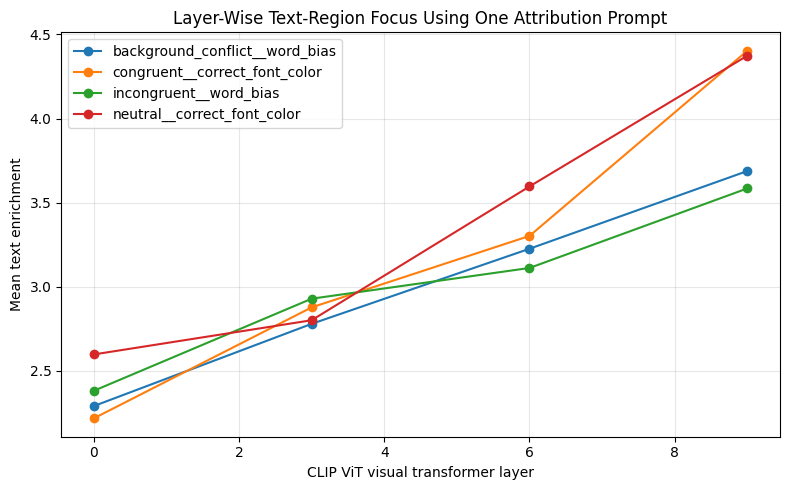

Saved plot: /content/stroop_clip_one_prompt_dataset/results/layerwise_text_enrichment_plot.png


In [26]:
plt.figure(figsize=(8, 5))

for group_name in layerwise_summary["group"].unique():
    group_data = layerwise_summary[layerwise_summary["group"] == group_name]

    plt.plot(
        group_data["layer"],
        group_data["mean_text_enrichment"],
        marker="o",
        label=group_name
    )

plt.xlabel("CLIP ViT visual transformer layer")
plt.ylabel("Mean text enrichment")
plt.title("Layer-Wise Text-Region Focus Using One Attribution Prompt")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plot_path = RESULTS_DIR / "layerwise_text_enrichment_plot.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved plot:", plot_path)

# 19. Final summary for professor

This cell prints a clean explanation with the actual accuracy values from your run.

In [30]:
def create_professor_summary():
    lines = []

    lines.append(" I replace the color placeholder with each color label and allow CLIP "
        "to select the prompt with the highest image-text similarity score."
    )
    lines.append("")
    lines.append(f"The overall font-color accuracy is {overall_accuracy:.4f}.")
    lines.append("")

    lines.append("Accuracy by condition:")
    for _, row in accuracy_by_condition.iterrows():
        lines.append(f"- {row['condition']}: {row['font_color_accuracy']:.4f}")

    lines.append("")
    lines.append("After prediction, I categorize each output as correct font color, word bias, background bias, or other error.")
    lines.append("This shows whether CLIP follows the real font color, the written word, or the background.")
    lines.append("")

    lines.append("White-box testing:")
    lines.append("For white-box testing, I use one attribution prompt based on the model's predicted label.")
    lines.append("For example, if CLIP predicts orange, I generate the heatmap for 'the text is written in orange'.")
    lines.append("This allows the heatmap to explain the model's actual decision instead of comparing multiple prompt types.")
    lines.append("")

    lines.append("Layer-wise white-box analysis:")
    lines.append(
        "To further analyze the model internally, I also perform layer-wise attribution across selected "
        "CLIP ViT-B/16 visual transformer layers, such as Layer 0, Layer 3, Layer 6, and Layer 9."
    )
    lines.append(
        "For each selected image, I use the same one attribution prompt based on the predicted label, "
        "and generate heatmaps at different transformer layers."
    )
    lines.append(
        "This helps show how the model's evidence changes from early visual layers to deeper visual layers."
    )
    lines.append(
        "I also use the binary text mask to calculate text-region focus metrics such as text energy share "
        "and text enrichment."
    )
    lines.append(
        "Text enrichment tells whether the heatmap is more concentrated on the text region than expected "
        "based on the text area alone."
    )
    lines.append("")

    lines.append("Current interpretation:")
    lines.append(
        "The goal is to check whether CLIP's wrong predictions in conflict cases are supported by the text region "
        "and whether those predictions align more with the written word than with the actual font color."
    )
    lines.append(
        "If a conflict image is classified as word bias and the heatmaps focus on the text region, "
        "then the result suggests that the model is using the text area but interpreting it in a word-biased way."
    )
    lines.append(
        "The layer-wise analysis strengthens this interpretation by showing whether the model's evidence becomes "
        "more concentrated around the text region in deeper visual transformer layers."
    )
    lines.append("")
    lines.append(
        "Overall, this helps test whether CLIP shows a Stroop-like word bias: under visual-semantic conflict, "
        "the model often follows the written word instead of the actual visual font color."
    )
    lines.append("")

    return "\n".join(lines)


summary_text = create_professor_summary()
print(summary_text)

summary_path = RESULTS_DIR / "professor_email_summary.txt"
with open(summary_path, "w") as f:
    f.write(summary_text)

print("\nSaved summary:", summary_path)

 I replace the color placeholder with each color label and allow CLIP to select the prompt with the highest image-text similarity score.

The overall font-color accuracy is 0.4451.

Accuracy by condition:
- background_conflict: 0.0140
- congruent: 1.0000
- incongruent: 0.0312
- neutral: 0.7354

After prediction, I categorize each output as correct font color, word bias, background bias, or other error.
This shows whether CLIP follows the real font color, the written word, or the background.

White-box testing:
For white-box testing, I use one attribution prompt based on the model's predicted label.
For example, if CLIP predicts orange, I generate the heatmap for 'the text is written in orange'.
This allows the heatmap to explain the model's actual decision instead of comparing multiple prompt types.

Layer-wise white-box analysis:
To further analyze the model internally, I also perform layer-wise attribution across selected CLIP ViT-B/16 visual transformer layers, such as Layer 0, Laye

# 20. How to interpret the final result

The black-box results tell us **what CLIP predicted**.

The white-box heatmaps help us understand **which image region supported the prediction**.

If a conflict image has:
- font color = yellow,
- word = ORANGE,
- prediction = orange,

then this is a `word_bias` error.

If the heatmap for:

```text
the text is written in orange
```

focuses on the text region, then the model's wrong prediction is supported by the region containing the written word.

So the conclusion is:

> CLIP often looks at the text region, but under Stroop-style conflict, it aligns that region more strongly with the written word than with the actual visual font color.